In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA
from scipy.constants import *

In [3]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

# td - drive-induced dephasing

In [4]:
header = "D:/K_sunada/result/CDY163/"
data = "/2024-07-31/2024-07-31T212707_3378b23e-drive_induced_dephasing"
dd = datadict_from_hdf5(header + data +"/data")

In [5]:
def Damping(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

def liner_func(power, alpha, const):
    return const + alpha*power

In [6]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

def dbm_watt(dBm):
    return (10**(dBm/10))*1e-3

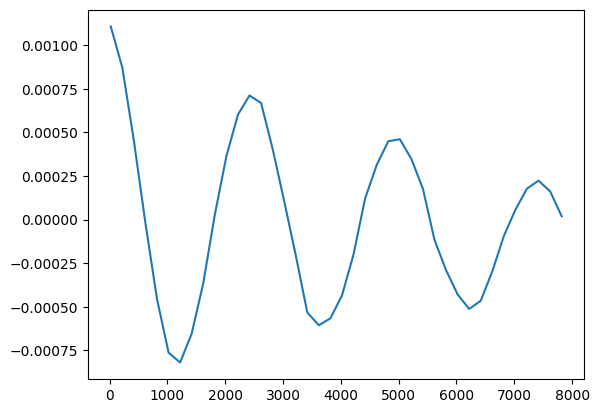

In [7]:
num_of_amp = 21
num_of_delay = 40
delay = []
s11 = []
amp = []
for i in range(num_of_amp):
    amplitude = dd['amplitude']['values'][num_of_delay*i]
    tau = dd['delay']['values'][num_of_delay*i:num_of_delay*(i+1)]
    s11_I = dd['s11']['values'][num_of_delay*i:num_of_delay*(i+1)].real
    s11_Q = dd['s11']['values'][num_of_delay*i:num_of_delay*(i+1)].imag
    s11_PCA = PCA_transform(s11_I, s11_Q)[0]
    amp.append(amplitude)
    delay.append(tau)
    s11.append(s11_PCA)
    
plt.plot(delay[5], s11[5])

In [8]:
par_ini = {'amp':0.0008,'gamma': 1/5000,'omega':2*np.pi/2500,'phi0':np.pi, 'const':0}
par_min = {'amp':-np.inf,'gamma': 0,'omega':-2*np.pi,'phi0':-2*np.pi,'const':-np.inf}
par_max = {'amp':np.inf,'gamma': np.inf,'omega':2*np.pi,'phi0':2*np.pi,'const':np.inf}
par_vary = {'amp':True,'gamma': True,'omega':True,'phi0':True,'const':True}
model = lmfit.Model(Damping)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])

results = []
for i in range(num_of_amp):
    result = model.fit(data = s11[i], params=params, delay = delay[i])
    results.append(result)

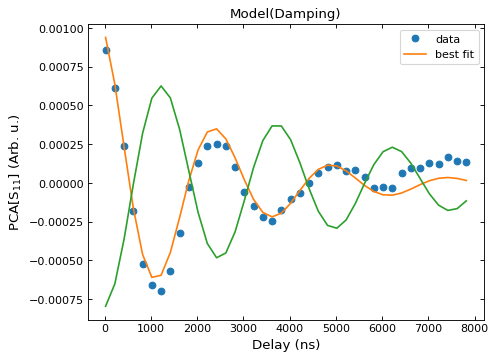

In [9]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(top='on',bottom='on`',left='on',right='on',)

results[id].plot_fit(ax = ax)
plt.plot(delay[0],results[0].init_fit)
ax.set_xlabel('Delay (ns)', size='large')
ax.set_ylabel('PCA[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

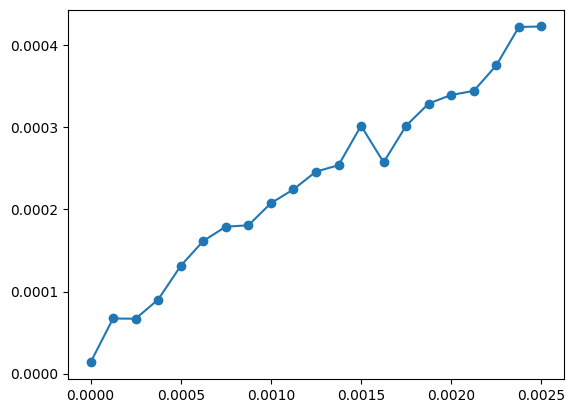

In [10]:
gamma = [1.3465e-05, 6.7097e-05, 6.6811e-05, 9.0183e-05, 1.3121e-04, 1.6158e-04, 1.7906e-04,
         1.8069e-04, 2.0763e-04, 2.2448e-04, 2.4617e-04, 2.5398e-04, 3.0207e-04, 2.5748e-04,
         3.0216e-04, 3.2916e-04, 3.3966e-04, 3.4458e-04, 3.7572e-04, 4.2253e-04, 4.2312e-04]
amp_squared = np.array(amp) ** 2

plt.plot(amp_squared, gamma, 'o-')

In [11]:
par_ini = {'alpha': 0.00005/0.001,'const':0e9}
par_min = {'alpha': -np.inf,'const':-np.inf}
par_max = {'alpha': np.inf,'const':np.inf}
par_vary = {'alpha': True,'const':True}
model = lmfit.Model(liner_func)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])

result = model.fit(data = gamma , params=params, power = amp_squared)

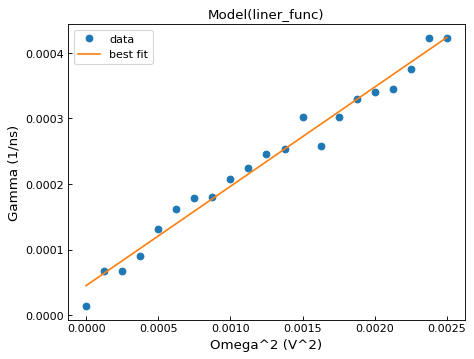

In [12]:
fig, ax = plt.subplots(dpi=80)
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
result.plot_fit(ax = ax)
ax.set_xlabel('Omega^2 (V^2)', size='large')
ax.set_ylabel('Gamma (1/ns)', size='large')
plt.legend()
plt.show()
result

In [16]:
target_freq = 9.35
read_freq_g = 9.3703
read_freq_e = 9.3680
chi = (read_freq_e - read_freq_g)/2
kappa_ex = 0.00005
kappa_in = 0.00134

# coeff = np.abs(S11_e - S11_g) ** 2 /2
kappa = kappa_ex + kappa_in
coeff = (kappa*chi)**2 / (2*(kappa**2/4 + (read_freq_g - target_freq)**2)*(kappa**2/4 + (read_freq_g + chi - target_freq)**2))
atten = hbar * target_freq * 1e9 * 2*np.pi* (0.15145193 * 1e9)/ coeff
atten_dbm = watt_dbm(atten)
print(f"attenuation rate (dBm): {atten_dbm}")

attenuation rate (dBm): -69.53642796821089


## cw acStark shift

In [ ]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k/((freq-center)**2 + (k/2)**2)

In [ ]:
def Gaussian(freq, amp, const, center, k):
    return const - amp*np.exp(-(freq-center)**2/(2*k**2))

In [ ]:
header = "D:/K_sunada/result/CDY155/"
# ac1037 = "/2023-12-29/2023-12-29T173725_7e58e084-cw_attenuation"
ac1033 = "/2024-02-17/2024-02-17T151122_5fc2ed6b-cw_attenuation"
# ac1031 = "/2023-12-25/2023-12-25T162657_fc4e3f61-cw_attenuation"
ac1030 = "/2024-02-17/2024-02-17T151927_80de451a-cw_attenuation" 
# ac1029 = "/2023-12-29/2023-12-29T171620_8c5c01d3-cw_attenuation"
ac1028 = "/2024-02-17/2024-02-17T150336_49d6dd1b-cw_attenuation"
ac1026 = "/2024-02-17/2024-02-17T145736_73524581-cw_attenuation"
ac1022 = "/2024-02-17/2024-02-17T145205_adcbe7a5-cw_attenuation"

# dd1037 = datadict_from_hdf5(header + ac1037+"/data")
dd1033 = datadict_from_hdf5(header + ac1033+"/data")
# dd1031 = datadict_from_hdf5(header + ac1031+"/data")
dd1030 = datadict_from_hdf5(header + ac1030+"/data")
# dd1029 = datadict_from_hdf5(header + ac1029 +"/data")
dd1028 = datadict_from_hdf5(header + ac1028 +"/data")
dd1026 = datadict_from_hdf5(header + ac1026 +"/data")
dd1022 = datadict_from_hdf5(header + ac1022+"/data")

10.3 GHz

In [ ]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1030['frequency']['values'][i]
    y_real = dd1030['s11']['values'][i].real
    y_imag = dd1030['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [ ]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.96e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

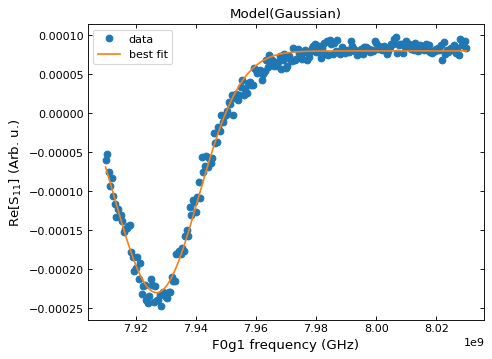

In [ ]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

In [ ]:
center1030_g = [7.9876e+09, 7.9856e+09, 7.9839e+09, 7.9821e+09, 7.9798e+09, 7.9778e+09,
                7.9753e+09, 7.9730e+09, 7.9706e+09, 7.9679e+09, 7.9649e+09, 7.9620e+09,
                7.9588e+09, 7.9553e+09, 7.9520e+09, 7.9483e+09, 7.9443e+09, 7.9404e+09,
                7.9358e+09, 7.9313e+09, 7.9269e+09]

10.28 GHz

In [ ]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1028['frequency']['values'][i]
    y_real = dd1028['s11']['values'][i].real
    y_imag = dd1028['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [ ]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.99e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

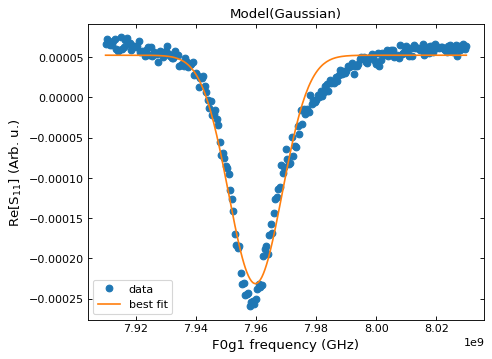

In [ ]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [ ]:
center1028_g = [7.9980e+09, 7.9969e+09, 7.9956e+09, 7.9943e+09, 7.9930e+09, 7.9917e+09,
                7.9904e+09, 7.9890e+09, 7.9873e+09, 7.9856e+09, 7.9839e+09, 7.9820e+09,
                7.9801e+09, 7.9779e+09, 7.9757e+09, 7.9734e+09, 7.9709e+09, 7.9685e+09,
                7.9658e+09, 7.9631e+09, 7.9598e+09]

10.26 GHz

In [ ]:
y = np.unique(dd1026['power']['values'])
x = np.unique(dd1026['frequency']['values'])
z = np.real(dd1026['s11']['values'])

In [ ]:
xs = []
ys = []
num_of_freq = 181

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1026['frequency']['values'][i]
    y_real = dd1026['s11']['values'][i].real
    y_imag = dd1026['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [ ]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.99e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

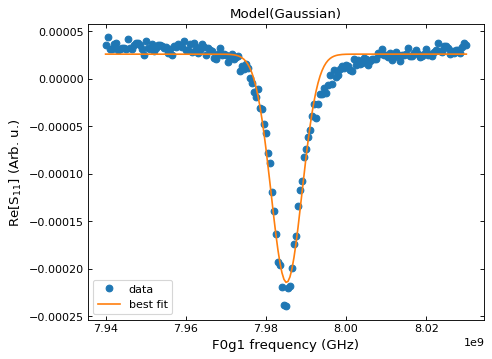

In [ ]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]

In [ ]:
center1026_g = [8.0063e+09, 8.0057e+09, 8.0050e+09, 8.0043e+09, 8.0037e+09, 8.0030e+09,
                8.0022e+09, 8.0014e+09, 8.0005e+09, 7.9994e+09, 7.9985e+09, 7.9975e+09,
                7.9964e+09, 7.9951e+09, 7.9940e+09, 7.9925e+09, 7.9912e+09, 7.9900e+09,
                7.9885e+09, 7.9869e+09, 7.9851e+09]

10.22 GHz

In [ ]:
xs = []
ys = []
num_of_freq = 101

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1022['frequency']['values'][i]
    y_real = dd1022['s11']['values'][i].real
    y_imag = dd1022['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [ ]:
par_ini = {'amp': 0.00035,'const':0, 'center':8.0e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

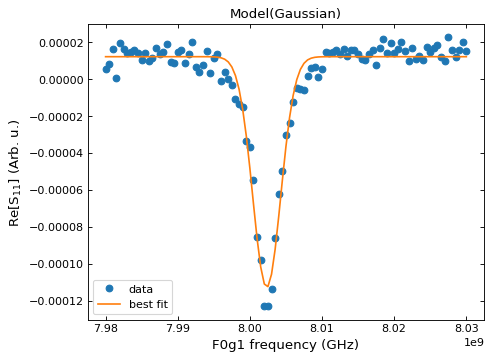

In [ ]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [ ]:
center1022_g = [8.0117e+09, 8.0115e+09, 8.0111e+09, 8.0109e+09, 8.0106e+09, 8.0102e+09, 
                8.0098e+09, 8.0096e+09, 8.0092e+09, 8.0087e+09, 8.0083e+09, 8.0078e+09,
                8.0073e+09, 8.0069e+09, 8.0063e+09, 8.0058e+09, 8.0051e+09, 8.0045e+09,
                8.0038e+09, 8.0032e+09, 8.0023e+09]

10.31 GHz

In [ ]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1031['frequency']['values'][i]
    y_real = dd1031['s11']['values'][i].real
    y_imag = dd1031['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

NameError: name 'dd1031' is not defined

In [ ]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.97e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

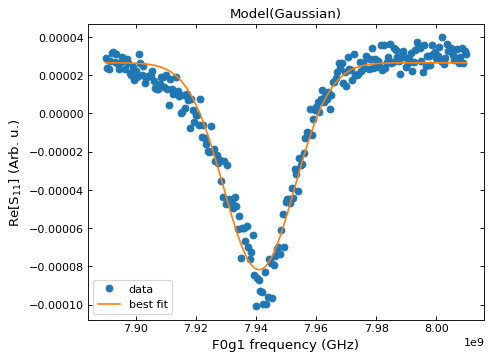

In [ ]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [ ]:
center1031_g = [7.9975e+09, 7.9959e+09, 7.9950e+09, 7.9923e+09, 7.9914e+09, 7.9886e+09, 7.9868e+09,
                7.9838e+09, 7.9821e+09, 7.9797e+09, 7.9772e+09, 7.9745e+09, 7.9710e+09, 7.9685e+09,
                7.9652e+09, 7.9614e+09, 7.9572e+09, 7.9537e+09, 7.9494e+09, 7.9456e+09, 7.9411e+09]

In [ ]:
center1031 = [7.9975e+09, 7.9959e+09, 7.9949e+09, 7.9925e+09, 7.9915e+09, 7.9887e+09, 7.9870e+09,
              7.9841e+09, 7.9824e+09, 7.9797e+09, 7.9773e+09, 7.9745e+09, 7.9635e+09, 7.9686e+09,
              7.9652e+09, 7.9616e+09, 7.9575e+09, 7.9538e+09, 7.9495e+09, 7.9458e+09, 7.9413e+09]

10.29 GHz

In [ ]:
xs = []
ys = []
num_of_freq = 241

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1029['frequency']['values'][i]
    y_real = dd1029['s11']['values'][i].real
    y_imag = dd1029['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [ ]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.97e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

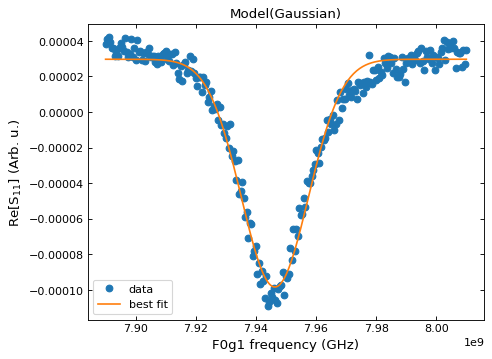

In [ ]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [ ]:
center1029_g = [7.9998e+09, 7.9983e+09, 7.9966e+09, 7.9950e+09, 7.9933e+09, 7.9914e+09, 7.9895e+09,
                7.9875e+09, 7.9852e+09, 7.9830e+09, 7.9804e+09, 7.9776e+09, 7.9749e+09, 7.9719e+09,
                7.9689e+09, 7.9654e+09, 7.9623e+09, 7.9584e+09, 7.9545e+09, 7.9506e+09, 7.9463e+09]

10.33 GHz

In [ ]:
xs = []
ys = []
num_of_freq = 181

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1033['frequency']['values'][i]
    y_real = dd1033['s11']['values'][i].real
    y_imag = dd1033['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [ ]:
par_ini = {'amp': 0.00035,'const':0, 'center':7.99e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

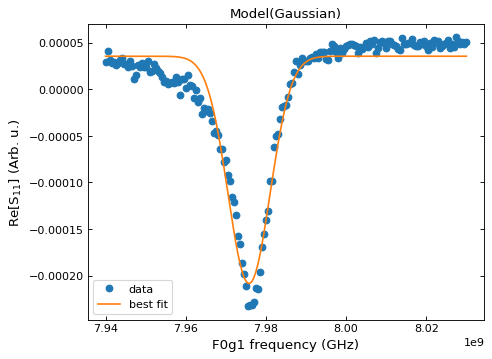

In [ ]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [ ]:
center1033_g = [8.0031e+09, 8.0024e+09, 8.0016e+09, 8.0007e+09, 7.9998e+09, 7.9989e+09,
                7.9978e+09, 7.9968e+09, 7.9958e+09, 7.9946e+09, 7.9935e+09, 7.9920e+09,
                7.9906e+09, 7.9890e+09, 7.9875e+09, 7.9858e+09, 7.9841e+09, 7.9820e+09,
                7.9802e+09, 7.9781e+09, 7.9758e+09]

10.37 GHz

In [ ]:
xs = []
ys = []
num_of_freq = 101

for i in range(21):
    ini = num_of_freq*i
    fin = num_of_freq*(1+i)-1
    x = dd1037['frequency']['values'][i]
    y_real = dd1037['s11']['values'][i].real
    y_imag = dd1037['s11']['values'][i].imag
    y_PCA = PCA_transform(y_real, y_imag)
    xs.append(x)
    ys.append(-y_PCA[0])

In [ ]:
par_ini = {'amp': 0.00035,'const':0, 'center':8.02e9,'k':0.01e9}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf, 'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True, 'center':True,'k':True}
model = lmfit.Model(Gaussian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
results = []
for i in range(21):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

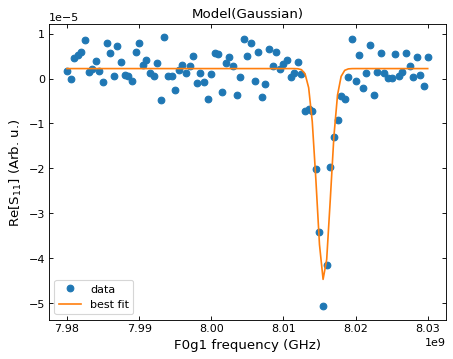

In [ ]:
fig, ax = plt.subplots(dpi=80)
id = 20
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()
results[id]


In [ ]:
center1037_g = [8.0214e+09, 8.0214e+09, 8.0212e+09, 8.0210e+09, 8.0208e+09, 8.0207e+09, 8.0203e+09,
                8.0202e+09, 8.0198e+09, 8.0196e+09, 8.0194e+09, 8.0192e+09, 8.0188e+09, 8.0184e+09,
                8.0181e+09, 8.0179e+09, 8.0173e+09, 8.0169e+09, 8.0166e+09, 8.0161e+09, 8.0156e+09]

In [ ]:
power_dBm = np.linspace(-10, -5, 21)
power_W = 10**((power_dBm)/10) *1e-3

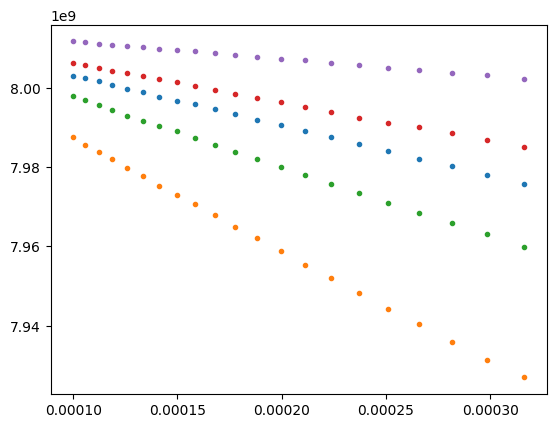

In [ ]:
# plt.plot(power_W, center1037_g, '.', label="10.37 GHz")
plt.plot(power_W, center1033_g, '.', label="10.33 GHz")
# plt.plot(power_W, center1031_g, '.', label="10.31 GHz")
plt.plot(power_W, center1030_g, '.', label="10.30 GHz")
# plt.plot(power_W, center1029_g, '.', label="10.29 GHz")
plt.plot(power_W, center1028_g, '.', label="10.28 GHz")
plt.plot(power_W, center1026_g, '.', label="10.26 GHz")
plt.plot(power_W, center1022_g, '.', label="10.22 GHz")

plt.show()

In [ ]:
def liner_func(power, alpha, const):
    return const - alpha*power

In [ ]:
par_ini = {'alpha': 0.015e9/0.00005,'const':8.005e9}
par_min = {'alpha': -np.inf,'const':-np.inf}
par_max = {'alpha': np.inf,'const':np.inf}
par_vary = {'alpha': True,'const':True}
model = lmfit.Model(liner_func)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
# result1037 = model.fit(data = center1037_g, params=params, power = power_W)
result1033 = model.fit(data = center1033_g, params=params, power = power_W)
# result1031 = model.fit(data = center1031_g, params=params, power = power_W)
result1030 = model.fit(data = center1030_g, params=params, power = power_W)
# result1029 = model.fit(data = center1029_g, params=params, power = power_W)
result1028 = model.fit(data = center1028_g, params=params, power = power_W)
result1026 = model.fit(data = center1026_g, params=params, power = power_W)
result1022 = model.fit(data = center1022_g, params=params, power = power_W)

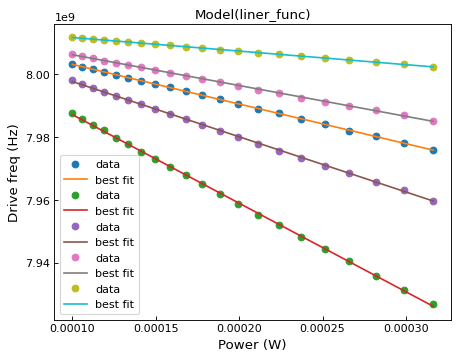

In [ ]:
fig, ax = plt.subplots(dpi=80)
plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
# result1037.plot_fit(ax = ax)
result1033.plot_fit(ax = ax)
# result1031.plot_fit(ax = ax)
result1030.plot_fit(ax = ax)
# result1029.plot_fit(ax = ax)
result1028.plot_fit(ax = ax)
result1026.plot_fit(ax = ax)
result1022.plot_fit(ax = ax)
ax.set_xlabel('Power (W)', size='large')
ax.set_ylabel('Drive freq (Hz)', size='large')
plt.legend()
plt.show()
result1022

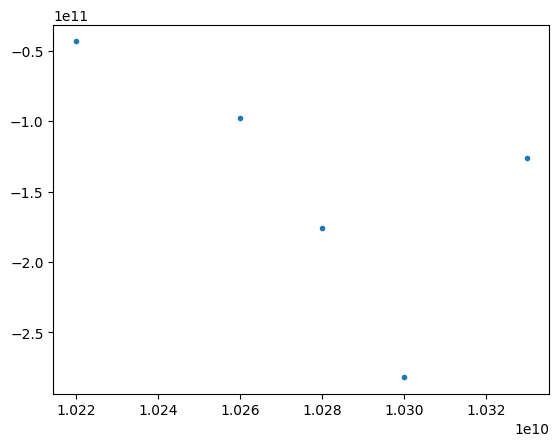

In [ ]:
x = np.array([10.33e9, 10.30e9, 10.28e9, 10.26e9, 10.22e9])
alpha = -np.array([1.2620e+11, 2.8194e+11, 1.7581e+11, 9.8051e+10, 	4.3243e+10])
plt.plot(x, alpha, '.')
plt.show()

In [ ]:
from scipy.constants import *

In [ ]:
# k_sunada - dpr model
# k_f =0.21238950e9
chi_Hz = -1500000.0
chi = chi_Hz*2*np.pi

# omega_p =np.array([10.37e9, 10.33e9, 10.31e9, 10.30e9,10.29e9, 10.28e9, 10.26e9, 10.22e9])*2*np.pi
# omega_f = 10.1676834e9 *2*np.pi
# omega_r =10.2557302e9*2*np.pi
omega_p=np.array([10.33e9, 10.30e9, 10.28e9, 10.26e9, 10.22e9])*2*np.pi

# g = 0.1011e9
# slope= np.array([-2.7268e+10, -1.3029e+11, -2.6321e+11, -2.8213e+11, -2.4807e+11,  -1.8144e+11, -1.0320e+11, -4.4706e+10])*2*np.pi
slope= -np.array([1.2620e+11, 2.8194e+11, 1.7581e+11, 9.8051e+10, 	4.3243e+10])*2*np.pi
P = 0.0002
# P_eff = P * g* k_f**0.5/(1j*(omega_f-omega_p)+k_f/2)/k_eff**0.5
Delta_q = np.array(slope*P * 2*np.pi)
# delta_f = omega_p-omega_f
# delta_r = omega_p-omega_r

def coeff2(k_f, delta_r, delta_f, g):
    numer = k_f *g**2/(delta_r**2)
    denom = (delta_f - g**2/delta_r)**2 +(k_f/2)**2
    return numer/denom

def ac_stark_shift1(omega,  omega_r, omega_f, k_f, g, alpha):
    return 2*chi*alpha/(hbar*omega)*coeff2(k_f=k_f, delta_r=omega-omega_r, delta_f=omega-omega_f, g=g)

In [ ]:
# x=np.array([10.37e9, 10.33e9, 10.31e9, 10.30e9,10.29e9, 10.28e9, 10.26e9, 10.22e9])*2*np.pi
# slope= np.array([-2.7268e+10, -1.3029e+11, -2.6321e+11, -2.8213e+11, -2.4807e+11,  -1.8144e+11, -1.0320e+11, -4.4706e+10])*2*np.pi

x=np.array([10.33e9, 10.30e9, 10.28e9, 10.26e9, 10.22e9])*2*np.pi
slope= -np.array([1.2620e+11, 2.8194e+11, 1.7581e+11, 9.8051e+10, 	4.3243e+10])*2*np.pi
par_ini = {'omega_r':10.267e9*2*np.pi, 'omega_f':10.176e9*2*np.pi,
           'k_f':0.20e9*2*np.pi,'g':0.083e9*2*np.pi, 'alpha':4.4e-11}
par_min = {'omega_r':0, 'omega_f':0,'k_f':0,'g':0, 'alpha':0}
par_max = {'omega_r':np.inf,'omega_f':np.inf, 'k_f':np.inf,'g':np.inf, 'alpha':np.inf}
par_vary = { 'omega_r':False,'omega_f':False, 'k_f':False,'g':False, 'alpha':True}
model = lmfit.Model(ac_stark_shift1)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result = model.fit(data = slope, params=params, omega =x )

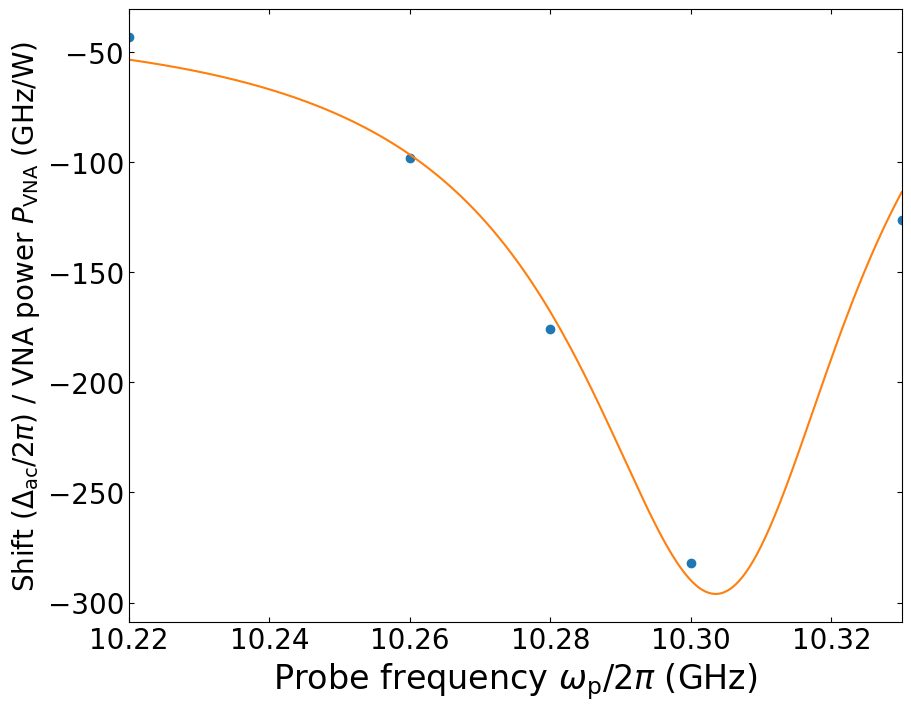

In [ ]:
fig, ax = plt.subplots(figsize=(9,7),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

# result.plot_fit(ax = ax)# result = model.fit(y, params, x=x)
x_interp = np.linspace(10.22e9, 10.33e9, 100*5)*2*np.pi
y_interp = result.model.func(x_interp, **result.best_values)
plt.xlim(10.22, 10.33)
plt.plot(x/(2*np.pi)*1e-9, slope/(2*np.pi)*1e-9,'o', label='original')
plt.plot(x_interp/(2*np.pi)*1e-9, y_interp/(2*np.pi)*1e-9, label='interpolated')
# ax.plot(x/(2*np.pi)*1e-9,result.init_fit/(2*np.pi)*1e-9)
ax.set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)', size='large')
ax.set_ylabel('Shift $(\Delta_\mathrm{ac}/2\pi)$ / VNA power $P_\mathrm{VNA}$ (GHz/W)')
plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
# plt.savefig('slope.png', bbox_inches='tight')
plt.show()

result

In [ ]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

def dbm_watt(dBm):
    return (10**(dBm/10))*1e-3

In [ ]:
watt_dbm(5.6292e-11*1e-3) + 50

-52.49553321005217

n_crit, n_ave

(10250000000.0, 10350000000.0)

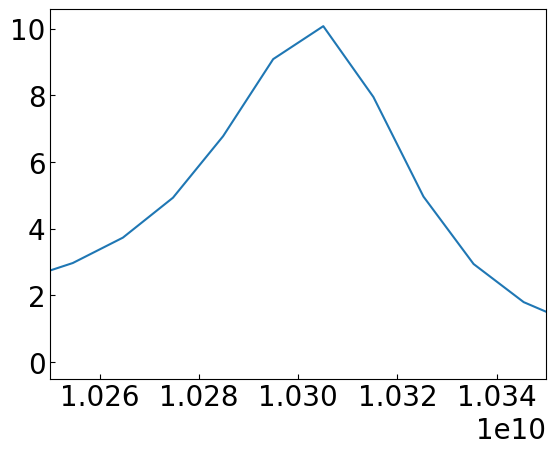

In [ ]:
omega = np.linspace(9.8, 10.8, 100)*1e9*2*np.pi
k_f = 2.0003e+08*2*np.pi
omega_f = 1.0177e+10 *2*np.pi
omega_r = 1.0267e+10 *2*np.pi
g = 82703425.3*2*np.pi
alpha = 5.7965e-11
Power = dbm_watt(-10)
n_ave = alpha*Power/(hbar*omega)*coeff2(k_f=k_f, delta_r=omega-omega_r, delta_f=omega-omega_f, g=g)
plt.plot(omega/(2*np.pi), n_ave)
plt.xlim(10.25e9, 10.35e9)

In [ ]:
readout_freq = 10.3
readout_lo_freq = 10.38 # 10.387
readout_if_freq = readout_lo_freq - readout_freq
JPA_if_freq = readout_freq * 2 - readout_lo_freq * 2

qubit_lo_freq = 7.85
ge_freq = 8.012+0.0089-2.8e-05
anharmonicity = 7.682-ge_freq+0.0208-6.5e-4
ge_if_freq = ge_freq-qubit_lo_freq
print(ge_freq, anharmonicity)

8.020872 -0.3187220000000003


In [ ]:
omega_q = 8.012e9*2*np.pi

omega_r = 1.0267e+10 *2*np.pi
delta = omega_q-omega_r
kai = -1500000 *2*np.pi
alpha = -0.3187e+9*2*np.pi
g = (kai*(delta+alpha)/2)**0.5


n_crit =( ((delta+2*alpha)/(2*g))**2-2)/5
delta, n_crit

(-14168582867.689964, 216.30429757417977)